# 01 — Data Understanding

This notebook loads the three raw datasets and checks their structure, quality, relationships, and click target before preprocessing.

## Install required packages

Run this cell once before running the analysis.

In [1]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

# This works when the notebook is launched from the repository root or its notebook folder.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in [current_dir, *current_dir.parents] if (path / "data" / "raw").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/raw. Start Jupyter inside this project.")

raw_dir = project_root / "data" / "raw"
interim_dir = project_root / "data" / "interim"
interim_dir.mkdir(parents=True, exist_ok=True)
print(f"Project root: {project_root}")

Project root: /Users/namees.local/Desktop/ensamble_technique


## Load the raw data

In [3]:
impressions = pd.read_csv(raw_dir / "impressions.csv", parse_dates=["event_ts"])
products = pd.read_csv(raw_dir / "product_catalog.csv")
users = pd.read_csv(raw_dir / "user_profile.csv")

datasets = {
    "impressions": impressions,
    "products": products,
    "users": users,
}

pd.DataFrame(
    [{"dataset": name, "rows": len(df), "columns": df.shape[1]} for name, df in datasets.items()]
).set_index("dataset")

,rows,columns
dataset,,
impressions,450000,11
products,1200,8
users,8000,5


## Preview and column types

In [4]:
for name, df in datasets.items():
    display(Markdown(f"### {name.title()}"))
    display(df.head())
    display(pd.DataFrame({"dtype": df.dtypes.astype(str), "non_null": df.notna().sum()}))

### Impressions

,impression_id,user_id,product_id,event_ts,platform,device_os,page_type,slot_position,hour_of_day,day_of_week,clicked
0,1,6166,838,2026-03-01 17:51:00,mobile_app,iOS,product_detail,1,6,Thu,0
1,2,840,807,2026-01-07 07:35:00,mobile_app,Android,search,1,19,Wed,0
2,3,7780,884,2026-04-22 06:44:00,mobile_app,iOS,category,2,0,Sun,0
3,4,4422,307,2026-04-29 23:10:00,website,Web,search,1,14,Sat,0
4,5,3620,804,2026-04-25 19:45:00,website,Web,product_detail,1,4,Mon,0


,dtype,non_null
impression_id,int64,450000
user_id,int64,450000
product_id,int64,450000
event_ts,datetime64[us],450000
platform,str,450000
device_os,str,450000
page_type,str,450000
slot_position,int64,450000
hour_of_day,int64,450000
day_of_week,str,450000


### Products

,product_id,product_name,brand,category,price_usd,discount_pct,avg_rating,review_count
0,1,New Balance Studio Yoga Mat,New Balance,Sports,45.490,12,4.400,229
1,2,Sony Bluetooth Speaker Gen 3,Sony,Electronics,339.950,2,4.000,188
2,3,Campbell's Family Size Tea Collection,Campbell's,Grocery,17.490,3,3.900,153
3,4,Calvin Klein Core Slim Fit Jeans,Calvin Klein,Fashion,68.950,16,3.900,124
4,5,Sony Wireless Earbuds Gen 3,Sony,Electronics,75.950,12,3.900,132


,dtype,non_null
product_id,int64,1200
product_name,str,1200
brand,str,1200
category,str,1200
price_usd,float64,1200
discount_pct,int64,1200
avg_rating,float64,1200
review_count,int64,1200


### Users

,user_id,age,gender,city,loyalty_tier
0,1,38,M,San Diego,Gold
1,2,24,M,San Antonio,Bronze
2,3,43,F,Chicago,Silver
3,4,45,F,Los Angeles,Gold
4,5,18,F,Houston,Bronze


,dtype,non_null
user_id,int64,8000
age,int64,8000
gender,str,8000
city,str,8000
loyalty_tier,str,8000


## Missing values and duplicate rows

In [5]:
quality_rows = []
for name, df in datasets.items():
    for column in df.columns:
        missing = int(df[column].isna().sum())
        quality_rows.append({
            "dataset": name,
            "column": column,
            "missing_count": missing,
            "missing_pct": 100 * missing / len(df),
            "unique_values": int(df[column].nunique(dropna=True)),
        })

quality = pd.DataFrame(quality_rows)
display(quality)
display(pd.DataFrame({
    "duplicate_rows": {name: int(df.duplicated().sum()) for name, df in datasets.items()}
}))

,dataset,column,missing_count,missing_pct,unique_values
0,impressions,impression_id,0,0.000,450000
1,impressions,user_id,0,0.000,8000
2,impressions,product_id,0,0.000,1200
3,impressions,event_ts,0,0.000,213195
4,impressions,platform,0,0.000,2
5,impressions,device_os,0,0.000,3
6,impressions,page_type,0,0.000,4
7,impressions,slot_position,0,0.000,6
8,impressions,hour_of_day,0,0.000,24
9,impressions,day_of_week,0,0.000,7


,duplicate_rows
impressions,0
products,0
users,0


## Numeric and categorical summaries

In [6]:
for name, df in datasets.items():
    display(Markdown(f"### {name.title()}: numeric columns"))
    numeric = df.select_dtypes(include="number")
    display(numeric.describe().T if not numeric.empty else Markdown("No numeric columns."))

    display(Markdown(f"### {name.title()}: categorical columns"))
    categorical = df.select_dtypes(include=["object", "category", "bool"])
    if categorical.empty:
        display(Markdown("No categorical columns."))
    else:
        for column in categorical.columns:
            display(Markdown(f"**{column}** — top values"))
            display(df[column].value_counts(dropna=False).head(10).to_frame("count"))

### Impressions: numeric columns

,count,mean,std,min,25%,50%,75%,max
impression_id,"450,000.000","225,000.500","129,903.955",1.000,"112,500.750","225,000.500","337,500.250","450,000.000"
user_id,"450,000.000","3,998.741","2,309.472",1.000,"1,995.000","4,000.000","5,996.000","8,000.000"
product_id,"450,000.000",598.496,347.247,1.000,298.000,596.000,899.000,"1,200.000"
slot_position,"450,000.000",2.649,1.532,1.000,1.000,2.000,4.000,6.000
hour_of_day,"450,000.000",11.494,6.929,0.000,5.000,11.000,18.000,23.000
clicked,"450,000.000",0.069,0.253,0.000,0.000,0.000,0.000,1.000


### Impressions: categorical columns

/var/folders/jk/n39x3th944zd1dk83rzfhfn00000gt/T/ipykernel_13097/3585427978.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=["object", "category", "bool"])


**platform** — top values

...

,count
gender,
M,3977
F,3875
Other,148


**city** — top values

,count
city,
Long Tail,1560
New York,796
Los Angeles,712
Chicago,644
Houston,589
Dallas,488
Philadelphia,451
Phoenix,427
San Antonio,368


**loyalty_tier** — top values

,count
loyalty_tier,
Silver,4104
Gold,2203
Platinum,881
Bronze,812


## Keys and relationships

In [7]:
relationship_checks = pd.Series({
    "duplicate impression_id values": int(impressions["impression_id"].duplicated().sum()),
    "duplicate product_id values in catalog": int(products["product_id"].duplicated().sum()),
    "duplicate user_id values in profiles": int(users["user_id"].duplicated().sum()),
    "impressions with unknown product_id": int((~impressions["product_id"].isin(products["product_id"])).sum()),
    "impressions with unknown user_id": int((~impressions["user_id"].isin(users["user_id"])).sum()),
}, name="count")
relationship_checks.to_frame()

,count
duplicate impression_id values,0
duplicate product_id values in catalog,0
duplicate user_id values in profiles,0
impressions with unknown product_id,0
impressions with unknown user_id,0


## Time coverage and target balance

,value
first event,2026-01-01 00:00:00
last event,2026-06-29 23:59:00
covered days,180
overall click rate,0.069


,rows,percent
clicked,,
0,419013,93.114
1,30987,6.886


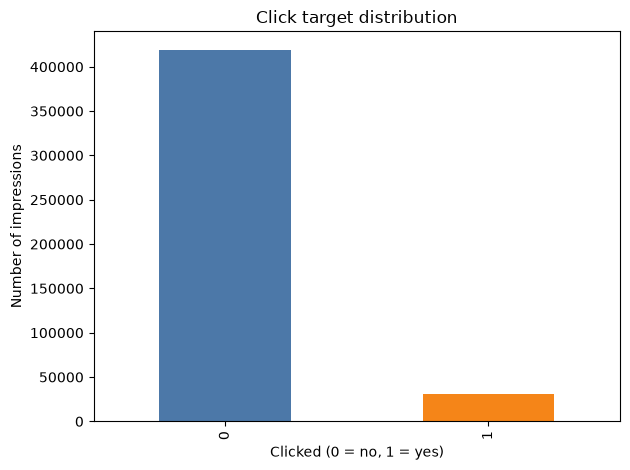

In [8]:
click_counts = impressions["clicked"].value_counts(dropna=False).sort_index()
click_rate = impressions["clicked"].mean()
time_summary = pd.Series({
    "first event": impressions["event_ts"].min(),
    "last event": impressions["event_ts"].max(),
    "covered days": impressions["event_ts"].dt.normalize().nunique(),
    "overall click rate": click_rate,
})
display(time_summary.to_frame("value"))
display(click_counts.to_frame("rows").assign(percent=lambda x: 100 * x["rows"] / len(impressions)))

ax = click_counts.plot(kind="bar", title="Click target distribution", color=["#4C78A8", "#F58518"])
ax.set_xlabel("Clicked (0 = no, 1 = yes)")
ax.set_ylabel("Number of impressions")
plt.tight_layout()
plt.show()

## Click rate across important groups

In [9]:
group_columns = ["platform", "device_os", "page_type", "slot_position", "hour_of_day", "day_of_week"]
for column in group_columns:
    summary = (
        impressions.groupby(column, dropna=False)["clicked"]
        .agg(impressions="size", clicks="sum", click_rate="mean")
        .sort_values("click_rate", ascending=False)
    )
    display(Markdown(f"### By {column}"))
    display(summary)

### By platform

,impressions,clicks,click_rate
platform,,,
website,103244,7534,0.073
mobile_app,346756,23453,0.068


### By device_os

,impressions,clicks,click_rate
device_os,,,
Web,103244,7534,0.073
Android,152192,10295,0.068
iOS,194564,13158,0.068


### By page_type

...

,impressions,clicks,click_rate
slot_position,,,
1,134974,13067,0.097
2,108059,8273,0.077
3,81313,4545,0.056
4,58191,2765,0.048
5,40344,1419,0.035
6,27119,918,0.034


### By hour_of_day

,impressions,clicks,click_rate
hour_of_day,,,
19,18832,1485,0.079
21,19024,1443,0.076
22,18749,1410,0.075
23,18685,1348,0.072
9,18693,1343,0.072
20,18764,1345,0.072
16,18608,1333,0.072
18,18583,1323,0.071
11,18929,1340,0.071


### By day_of_week

,impressions,clicks,click_rate
day_of_week,,,
Sun,62894,4494,0.071
Sat,67703,4674,0.069
Wed,63200,4356,0.069
Fri,67614,4633,0.069
Thu,63132,4322,0.068
Tue,62717,4276,0.068
Mon,62740,4232,0.067


## Join all three datasets and save the interim file

In [10]:
joined = (
    impressions
    .merge(products, on="product_id", how="left", validate="many_to_one")
    .merge(users, on="user_id", how="left", validate="many_to_one")
)

joined_path = interim_dir / "click_data_joined.csv"
joined.to_csv(joined_path, index=False)

join_summary = pd.DataFrame({
    "dataset": ["impressions", "product_catalog", "user_profile", "joined"],
    "rows": [len(impressions), len(products), len(users), len(joined)],
    "columns": [impressions.shape[1], products.shape[1], users.shape[1], joined.shape[1]],
}).set_index("dataset")
display(join_summary)
display(joined.head())
print(f"Saved joined data to: {joined_path}")

,rows,columns
dataset,,
impressions,450000,11
product_catalog,1200,8
user_profile,8000,5
joined,450000,22


,impression_id,user_id,product_id,event_ts,platform,device_os,page_type,slot_position,hour_of_day,day_of_week,clicked,product_name,brand,category,price_usd,discount_pct,avg_rating,review_count,age,gender,city,loyalty_tier
0,1,6166,838,2026-03-01 17:51:00,mobile_app,iOS,product_detail,1,6,Thu,0,KitchenAid Compact Cordless Vacuum,KitchenAid,Home,602.950,7,4.200,385,41,F,Philadelphia,Silver
1,2,840,807,2026-01-07 07:35:00,mobile_app,Android,search,1,19,Wed,0,Dyson Everyday Bedding Set,Dyson,Home,109.990,1,3.700,62,31,F,Dallas,Platinum
2,3,7780,884,2026-04-22 06:44:00,mobile_app,iOS,category,2,0,Sun,0,The Golden Signal - Workbook,Simon & Schuster,Books,12.990,5,3.500,273,39,M,Long Tail,Gold
3,4,4422,307,2026-04-29 23:10:00,website,Web,search,1,14,Sat,0,Apple Tablet Plus,Apple,Electronics,174.990,2,4.400,94,43,M,Philadelphia,Gold
4,5,3620,804,2026-04-25 19:45:00,website,Web,product_detail,1,4,Mon,0,Nike Heritage Graphic Tee,Nike,Fashion,38.950,7,4.000,62,32,F,Charlotte,Silver


Saved joined data to: /Users/namees.local/Desktop/ensamble_technique/data/interim/click_data_joined.csv


## Quick recap

In [11]:
missing_total = sum(int(df.isna().sum().sum()) for df in datasets.values())
duplicate_total = sum(int(df.duplicated().sum()) for df in datasets.values())
unknown_users = int((~impressions["user_id"].isin(users["user_id"])).sum())
unknown_products = int((~impressions["product_id"].isin(products["product_id"])).sum())
minority_share = min(click_rate, 1 - click_rate)
balance_note = (
    "The click target is uneven, so accuracy alone may be misleading."
    if minority_share < 0.30
    else "The click target is reasonably balanced."
)

display(Markdown(f"""
### What we learned

- The main table has **{len(impressions):,} impressions**. It connects to **{len(users):,} users** and **{len(products):,} products**.
- The data runs from **{impressions['event_ts'].min():%Y-%m-%d}** to **{impressions['event_ts'].max():%Y-%m-%d}**.
- The overall click rate is **{click_rate:.2%}**. {balance_note}
- We found **{missing_total:,} missing values** and **{duplicate_total:,} fully duplicated rows** across the three files.
- **{unknown_users:,} impressions** have an unknown user and **{unknown_products:,} impressions** have an unknown product. These numbers should be zero before joining the tables.
- The joined file has **{joined.shape[0]:,} rows** and **{joined.shape[1]} columns**. It was saved to `data/interim/click_data_joined.csv`.
- The next step is to clean any problems found here and build model-ready features.
"""))


### What we learned

- The main table has **450,000 impressions**. It connects to **8,000 users** and **1,200 products**.
- The data runs from **2026-01-01** to **2026-06-29**.
- The overall click rate is **6.89%**. The click target is uneven, so accuracy alone may be misleading.
- We found **0 missing values** and **0 fully duplicated rows** across the three files.
- **0 impressions** have an unknown user and **0 impressions** have an unknown product. These numbers should be zero before joining the tables.
- The joined file has **450,000 rows** and **22 columns**. It was saved to `data/interim/click_data_joined.csv`.
- The next step is to clean any problems found here and build model-ready features.
